# Train TRRUST Classifiers

Train binary (Relationship vs None) and ternary (Activation vs Repression vs None)
classifiers on TRRUST transcription factor–target gene relationships using
pre-computed scGPT gene embeddings.

In [1]:
import warnings

warnings.filterwarnings("ignore")

from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import torch
from sklearn.metrics import classification_report
from sklearn.model_selection import StratifiedKFold, train_test_split
from torch.utils.data import DataLoader, TensorDataset

from scfm_utils.scgpt import load_average_gene_embeddings
from scfm_utils.trrust import (
    BINARY_LABEL_NAMES,
    BINARY_LABELS,
    TERNARY_LABEL_NAMES,
    TERNARY_LABELS,
    TRRClassifierModel,
    load_binary_trrust_data,
    load_ternary_trrust_data,
)

## Configuration

In [ ]:
EMBEDDINGS_PATH = Path("../data/immune_bc_embeddings.h5ad")
TRRUST_PATH = Path("../data/trrust_rawdata.human.tsv")
DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")

BATCH_SIZE = 64
LR = 1e-3
BINARY_EPOCHS = 12
TERNARY_EPOCHS = 24

print(f"Device: {DEVICE}")
print(f"Embeddings: {EMBEDDINGS_PATH}")
print(f"TRRUST: {TRRUST_PATH}")

Device: cuda
Embeddings: ../data/immune_bc_embeddings.h5ad
TRRUST: ../data/trrust_rawdata.human.tsv


## Load model and data

In [3]:
avgs, gene_names = load_average_gene_embeddings(EMBEDDINGS_PATH)
mean_embeddings = np.mean(np.stack(list(avgs.values())), axis=0)
gene_embeddings = {name: mean_embeddings[i] for i, name in enumerate(gene_names)}
embsize = mean_embeddings.shape[1]

binary_data = load_binary_trrust_data(TRRUST_PATH, gene_embeddings)
ternary_data = load_ternary_trrust_data(TRRUST_PATH, gene_embeddings)

print(f"Gene embeddings: {len(gene_embeddings)} genes, {embsize}d (averaged over {len(avgs)} cell types)")
print(f"\nBinary samples: {len(binary_data.records)}")
for label_id, name in BINARY_LABEL_NAMES.items():
    print(f"  {name}: {(binary_data.labels == label_id).sum()}")
print(f"\nTernary samples: {len(ternary_data.records)}")
for label_id, name in TERNARY_LABEL_NAMES.items():
    print(f"  {name}: {(ternary_data.labels == label_id).sum()}")

Gene embeddings: 1173 genes, 512d (averaged over 16 cell types)

Binary samples: 712
  None: 356
  Relationship: 356

Ternary samples: 294
  Activation: 123
  Repression: 73
  None: 98


## Train Binary TRRUST Classifier

### 90/10 Stratified Train-Test Split

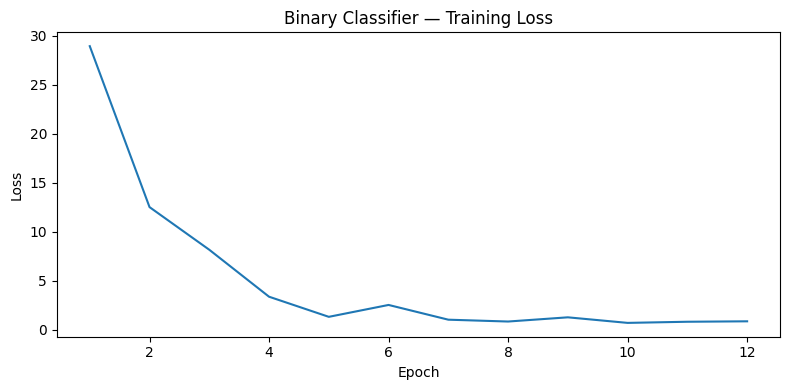

              precision    recall  f1-score   support

        None       0.78      0.78      0.78        36
Relationship       0.78      0.78      0.78        36

    accuracy                           0.78        72
   macro avg       0.78      0.78      0.78        72
weighted avg       0.78      0.78      0.78        72



In [4]:
tf_tensor = torch.from_numpy(binary_data.tf_embeddings).float()
tgt_tensor = torch.from_numpy(binary_data.target_embeddings).float()
label_tensor = torch.from_numpy(binary_data.labels).long()

n_classes = len(BINARY_LABELS)

train_idx, test_idx = train_test_split(
    np.arange(len(label_tensor)), test_size=0.1, stratify=binary_data.labels, random_state=42
)

train_ds = TensorDataset(tf_tensor[train_idx], tgt_tensor[train_idx], label_tensor[train_idx])
test_ds = TensorDataset(tf_tensor[test_idx], tgt_tensor[test_idx], label_tensor[test_idx])
train_loader = DataLoader(train_ds, batch_size=BATCH_SIZE, shuffle=True)
test_loader = DataLoader(test_ds, batch_size=BATCH_SIZE)

classifier = TRRClassifierModel(embsize=embsize, n_classes=n_classes).to(DEVICE)
optimizer = torch.optim.Adam(classifier.parameters(), lr=LR)
criterion = torch.nn.CrossEntropyLoss()

losses = []
for epoch in range(BINARY_EPOCHS):
    classifier.train()
    epoch_loss = 0.0
    for tf_b, tgt_b, lbl_b in train_loader:
        tf_b, tgt_b, lbl_b = tf_b.to(DEVICE), tgt_b.to(DEVICE), lbl_b.to(DEVICE)
        logits = classifier(tf_b, tgt_b)
        loss = criterion(logits, lbl_b)
        optimizer.zero_grad()
        loss.backward()
        optimizer.step()
        epoch_loss += loss.item() * len(lbl_b)
    losses.append(epoch_loss / len(train_idx))

plt.figure(figsize=(8, 4))
plt.plot(range(1, BINARY_EPOCHS + 1), losses)
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("Binary Classifier — Training Loss")
plt.tight_layout()
plt.show()

classifier.eval()
all_preds = []
with torch.no_grad():
    for tf_b, tgt_b, lbl_b in test_loader:
        logits = classifier(tf_b.to(DEVICE), tgt_b.to(DEVICE))
        all_preds.append(logits.argmax(dim=1).cpu())
all_preds = torch.cat(all_preds).numpy()

target_names = [BINARY_LABEL_NAMES[i] for i in range(n_classes)]
print(classification_report(binary_data.labels[test_idx], all_preds, target_names=target_names))

### Stratified 5-Fold Cross-Validation (no class weights)

In [5]:
skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

all_preds = np.zeros(len(label_tensor), dtype=np.int64)

for fold, (train_idx, test_idx) in enumerate(skf.split(tf_tensor, label_tensor)):
    train_ds = TensorDataset(tf_tensor[train_idx], tgt_tensor[train_idx], label_tensor[train_idx])
    test_ds = TensorDataset(tf_tensor[test_idx], tgt_tensor[test_idx], label_tensor[test_idx])
    train_loader = DataLoader(train_ds, batch_size=BATCH_SIZE, shuffle=True)
    test_loader = DataLoader(test_ds, batch_size=BATCH_SIZE)

    classifier = TRRClassifierModel(embsize=embsize, n_classes=n_classes).to(DEVICE)
    optimizer = torch.optim.Adam(classifier.parameters(), lr=LR)
    criterion = torch.nn.CrossEntropyLoss()

    for epoch in range(BINARY_EPOCHS):
        classifier.train()
        for tf_b, tgt_b, lbl_b in train_loader:
            tf_b, tgt_b, lbl_b = tf_b.to(DEVICE), tgt_b.to(DEVICE), lbl_b.to(DEVICE)
            logits = classifier(tf_b, tgt_b)
            loss = criterion(logits, lbl_b)
            optimizer.zero_grad()
            loss.backward()
            optimizer.step()

    classifier.eval()
    fold_preds = []
    with torch.no_grad():
        for tf_b, tgt_b, lbl_b in test_loader:
            logits = classifier(tf_b.to(DEVICE), tgt_b.to(DEVICE))
            fold_preds.append(logits.argmax(dim=1).cpu())
    fold_preds = torch.cat(fold_preds).numpy()
    all_preds[test_idx] = fold_preds

    fold_acc = (fold_preds == binary_data.labels[test_idx]).mean()
    print(f"Fold {fold + 1}: accuracy={fold_acc:.3f} (n={len(test_idx)})")

target_names = [BINARY_LABEL_NAMES[i] for i in range(n_classes)]
print(classification_report(binary_data.labels, all_preds, target_names=target_names))

Fold 1: accuracy=0.510 (n=143)
Fold 2: accuracy=0.573 (n=143)
Fold 3: accuracy=0.648 (n=142)
Fold 4: accuracy=0.648 (n=142)
Fold 5: accuracy=0.500 (n=142)
              precision    recall  f1-score   support

        None       0.56      0.69      0.62       356
Relationship       0.60      0.47      0.52       356

    accuracy                           0.58       712
   macro avg       0.58      0.58      0.57       712
weighted avg       0.58      0.58      0.57       712



## Train Ternary TRRUST Classifier

### 90/10 Stratified Train-Test Split

Class weights:
  Activation: 0.797 (n=123)
  Repression: 1.342 (n=73)
  None: 1.000 (n=98)


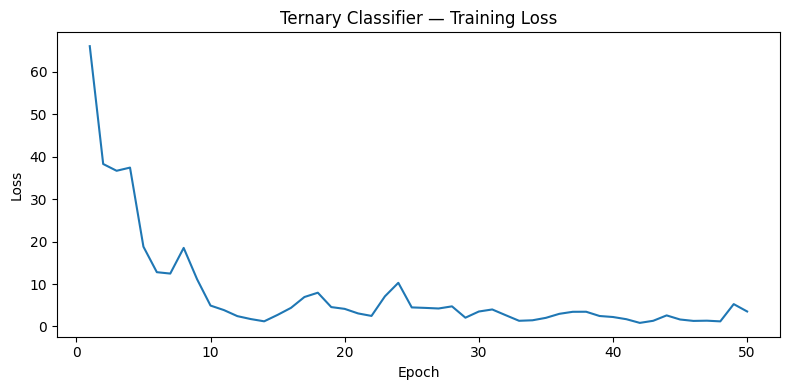

              precision    recall  f1-score   support

  Activation       0.67      0.31      0.42        13
  Repression       0.25      0.86      0.39         7
        None       0.00      0.00      0.00        10

    accuracy                           0.33        30
   macro avg       0.31      0.39      0.27        30
weighted avg       0.35      0.33      0.27        30



In [6]:
tf_tensor = torch.from_numpy(ternary_data.tf_embeddings).float()
tgt_tensor = torch.from_numpy(ternary_data.target_embeddings).float()
label_tensor = torch.from_numpy(ternary_data.labels).long()

n_classes = len(TERNARY_LABELS)
class_counts = torch.bincount(label_tensor, minlength=n_classes).float()
class_weights = (len(label_tensor) / (n_classes * class_counts)).to(DEVICE)

print("Class weights:")
for label_id, name in TERNARY_LABEL_NAMES.items():
    print(f"  {name}: {class_weights[label_id]:.3f} (n={int(class_counts[label_id])})")

train_idx, test_idx = train_test_split(
    np.arange(len(label_tensor)), test_size=0.1, stratify=ternary_data.labels, random_state=42
)

train_ds = TensorDataset(tf_tensor[train_idx], tgt_tensor[train_idx], label_tensor[train_idx])
test_ds = TensorDataset(tf_tensor[test_idx], tgt_tensor[test_idx], label_tensor[test_idx])
train_loader = DataLoader(train_ds, batch_size=BATCH_SIZE, shuffle=True)
test_loader = DataLoader(test_ds, batch_size=BATCH_SIZE)

classifier = TRRClassifierModel(embsize=embsize, n_classes=n_classes).to(DEVICE)
optimizer = torch.optim.Adam(classifier.parameters(), lr=LR)
criterion = torch.nn.CrossEntropyLoss(weight=class_weights)

losses = []
for epoch in range(TERNARY_EPOCHS):
    classifier.train()
    epoch_loss = 0.0
    for tf_b, tgt_b, lbl_b in train_loader:
        tf_b, tgt_b, lbl_b = tf_b.to(DEVICE), tgt_b.to(DEVICE), lbl_b.to(DEVICE)
        logits = classifier(tf_b, tgt_b)
        loss = criterion(logits, lbl_b)
        optimizer.zero_grad()
        loss.backward()
        optimizer.step()
        epoch_loss += loss.item() * len(lbl_b)
    losses.append(epoch_loss / len(train_idx))

plt.figure(figsize=(8, 4))
plt.plot(range(1, TERNARY_EPOCHS + 1), losses)
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("Ternary Classifier — Training Loss")
plt.tight_layout()
plt.show()

classifier.eval()
all_preds = []
with torch.no_grad():
    for tf_b, tgt_b, lbl_b in test_loader:
        logits = classifier(tf_b.to(DEVICE), tgt_b.to(DEVICE))
        all_preds.append(logits.argmax(dim=1).cpu())
all_preds = torch.cat(all_preds).numpy()

target_names = [TERNARY_LABEL_NAMES[i] for i in range(n_classes)]
print(classification_report(ternary_data.labels[test_idx], all_preds, target_names=target_names))

### Stratified 5-Fold Cross-Validation (using class weights)

In [7]:
skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

all_preds = np.zeros(len(label_tensor), dtype=np.int64)

for fold, (train_idx, test_idx) in enumerate(skf.split(tf_tensor, label_tensor)):
    train_ds = TensorDataset(tf_tensor[train_idx], tgt_tensor[train_idx], label_tensor[train_idx])
    test_ds = TensorDataset(tf_tensor[test_idx], tgt_tensor[test_idx], label_tensor[test_idx])
    train_loader = DataLoader(train_ds, batch_size=BATCH_SIZE, shuffle=True)
    test_loader = DataLoader(test_ds, batch_size=BATCH_SIZE)

    classifier = TRRClassifierModel(embsize=embsize, n_classes=n_classes).to(DEVICE)
    optimizer = torch.optim.Adam(classifier.parameters(), lr=LR)
    criterion = torch.nn.CrossEntropyLoss()

    for epoch in range(TERNARY_EPOCHS):
        classifier.train()
        for tf_b, tgt_b, lbl_b in train_loader:
            tf_b, tgt_b, lbl_b = tf_b.to(DEVICE), tgt_b.to(DEVICE), lbl_b.to(DEVICE)
            logits = classifier(tf_b, tgt_b)
            loss = criterion(logits, lbl_b)
            optimizer.zero_grad()
            loss.backward()
            optimizer.step()

    classifier.eval()
    fold_preds = []
    with torch.no_grad():
        for tf_b, tgt_b, lbl_b in test_loader:
            logits = classifier(tf_b.to(DEVICE), tgt_b.to(DEVICE))
            fold_preds.append(logits.argmax(dim=1).cpu())
    fold_preds = torch.cat(fold_preds).numpy()
    all_preds[test_idx] = fold_preds

    fold_acc = (fold_preds == ternary_data.labels[test_idx]).mean()
    print(f"Fold {fold + 1}: accuracy={fold_acc:.3f} (n={len(test_idx)})")

target_names = [TERNARY_LABEL_NAMES[i] for i in range(n_classes)]
print(classification_report(ternary_data.labels, all_preds, target_names=target_names))

Fold 1: accuracy=0.542 (n=59)
Fold 2: accuracy=0.508 (n=59)
Fold 3: accuracy=0.508 (n=59)
Fold 4: accuracy=0.593 (n=59)
Fold 5: accuracy=0.448 (n=58)
              precision    recall  f1-score   support

  Activation       0.52      0.72      0.61       123
  Repression       0.40      0.22      0.28        73
        None       0.58      0.49      0.53        98

    accuracy                           0.52       294
   macro avg       0.50      0.48      0.47       294
weighted avg       0.51      0.52      0.50       294

